In [22]:
from pathlib import Path

path = Path("../data/06_training_data/training_2026-07-31.h5")

print(path.exists())
print(path.stat().st_size / 1024**2, "MB")

True
4613.1943359375 MB


In [23]:
import h5py

with h5py.File(path, "r") as f:
    print(list(f.keys()))

['X', 'X_err', 'gaia_source_id', 'gaia_wavelength_nm', 'sdss_obj_id', 'sdss_wavelength_aa', 'y', 'y_ivar']


In [24]:
with h5py.File(path, "r") as f:
    print("X:", f["X"].shape)
    print("X_err:", f["X_err"].shape)
    print("X_id:", f["gaia_source_id"].shape)
    print("y:", f["y"].shape)
    print("y_id:", f["sdss_obj_id"].shape)
    print("y_ivar:", f["y_ivar"].shape)
    print("gaia wavelengths:", f["gaia_wavelength_nm"].shape)
    print("sdss wavelengths:", f["sdss_wavelength_aa"].shape)

X: (153272, 343)
X_err: (153272, 343)
X_id: (153272,)
y: (153272, 3600)
y_id: (153272,)
y_ivar: (153272, 3600)
gaia wavelengths: (343,)
sdss wavelengths: (3600,)


In [25]:
import numpy as np

with h5py.File(path, "r") as f:
    X = f["X"][:]
    X_err = f["X_err"][:]
    y = f["y"][:]
    y_ivar = f["y_ivar"][:]
    
    gaia_wavelength = f["gaia_wavelength_nm"][:]
    sdss_wavelength = f["sdss_wavelength_aa"][:]
    X_id = f["gaia_source_id"][:]
    y_id = f["sdss_obj_id"][:]


print(X.shape)
print(y.shape)
print(X_id.shape)
print(y_id.shape)

(153272, 343)
(153272, 3600)
(153272,)
(153272,)


In [26]:
# Borramos duplicados
result = np.unique(X_id, axis=0, return_index=True)
unique_index = result[1]

print("Espectros antes:", X_id.shape[0])
print("Duplicados eliminados:", X_id.shape[0] - len(unique_index))

# Filtramos por los mismos índices únicos
X = X[unique_index]
X_err = X_err[unique_index]

y = y[unique_index]
y_ivar = y_ivar[unique_index]

X_id = X_id[unique_index]
y_id = y_id[unique_index]

print("Espectros después:", X_id.shape[0])

Espectros antes: 153272
Duplicados eliminados: 102629
Espectros después: 50643


In [27]:
# Multiplicamos por 10 Gaia para estar en la misma escala de longitud de onda
gaia_wavelength = gaia_wavelength*10
# Convertimos las medidas de Gaia a la misma unidad que SDSS
X = X / 1e-19
X_err = X_err / 1e-19

# Nos quedamos solo con el intervalo común de ambos datos 
gaia_mask = (gaia_wavelength >= 5000) & (gaia_wavelength <= 9000)
sdss_mask = (sdss_wavelength >= 5000) & (sdss_wavelength <= 9000)

X = X[:, gaia_mask]
X_err = X_err[:, gaia_mask]

y = y[:, sdss_mask]
y_ivar =y_ivar[:, sdss_mask]

gaia_wavelength = gaia_wavelength[gaia_mask]
sdss_wavelength = sdss_wavelength[sdss_mask]

print(X.shape)
print(y.shape)

(50643, 201)
(50643, 2666)


In [28]:
valid_mask = (
    np.all(np.isfinite(X), axis=1)
    & np.all(np.isfinite(y), axis=1)
    & np.all(np.isfinite(X_err) & (X_err > 0), axis=1)
    & np.all(np.isfinite(y_ivar) & (y_ivar >= 0), axis=1)
)

X = X[valid_mask]
X_err = X_err[valid_mask]

y = y[valid_mask]
y_ivar = y_ivar[valid_mask]

X_id = X_id[valid_mask]
y_id = y_id[valid_mask]

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def plot_random_examples(
    X,
    y,
    gaia_wavelength,
    sdss_wavelength,
    gaia_ID,
    sdss_ID,
    n_examples=5,
    seed=None
):

    rng = np.random.default_rng(seed)
    n_samples = X.shape[0]

    random_indices = rng.choice(
        n_samples,
        size=min(n_examples, n_samples),
        replace=False
    )

    for idx in random_indices:
        plt.figure(figsize=(11, 5))

        plt.plot(
            sdss_wavelength,
            y[idx],
            label="Espectro observado por SDSS",
            linewidth=1.2
        )

        plt.plot(
            gaia_wavelength,
            X[idx],
            label="Espectro observado por Gaia",
            linewidth=1.2,
            alpha=0.8
        )

        plt.xlabel("Longitud de onda [Å]")
        plt.ylabel("Flujo")
        plt.title(
            f"Gaia source_id: {gaia_ID[idx]} | SDSS obj_id: {sdss_ID[idx]}"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return random_indices

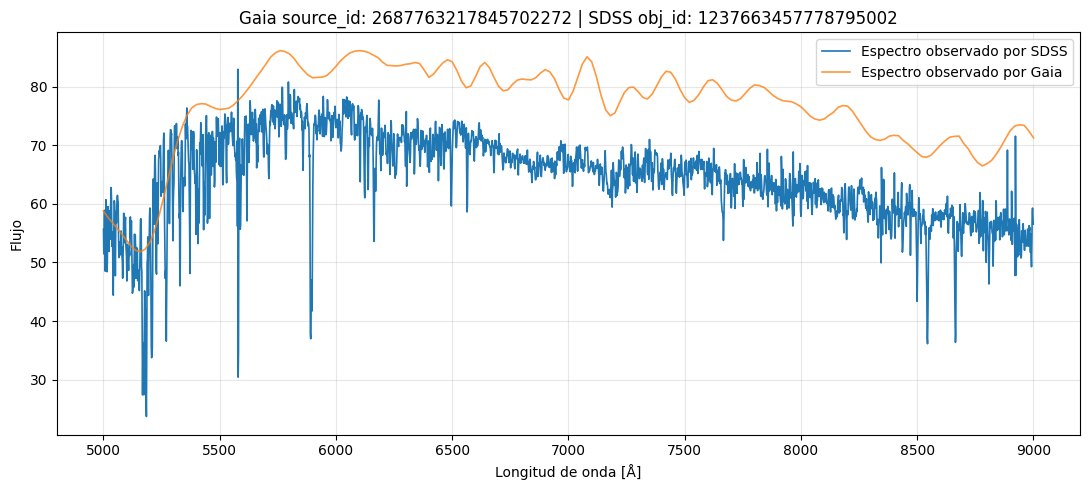

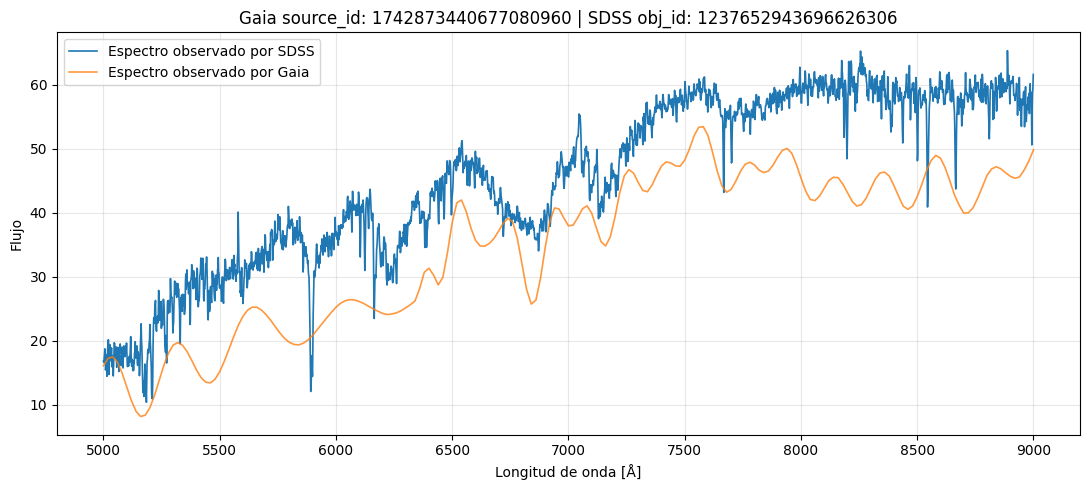

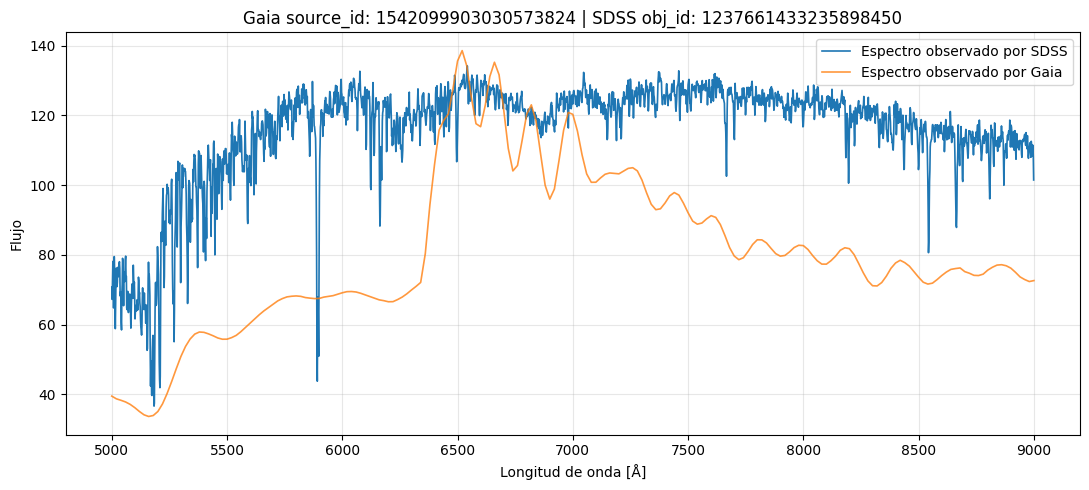

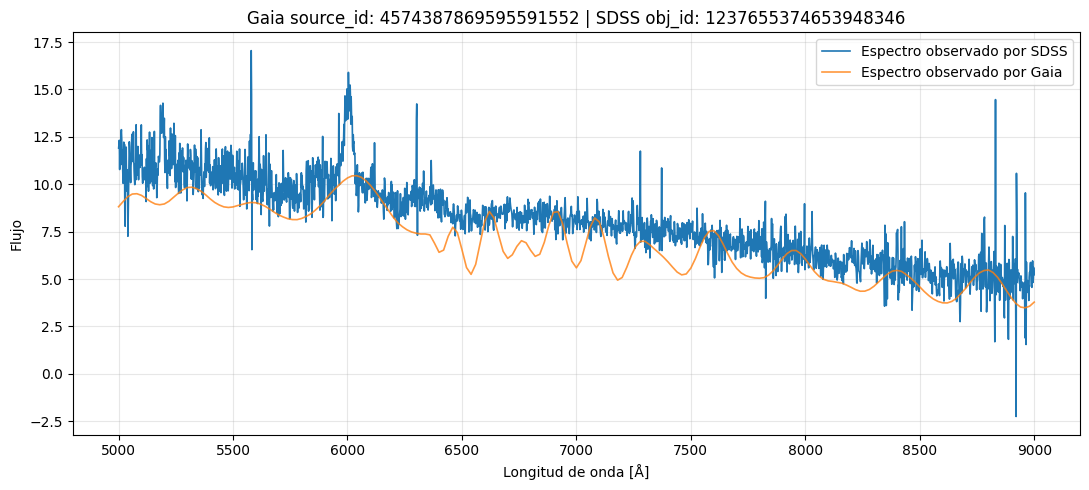

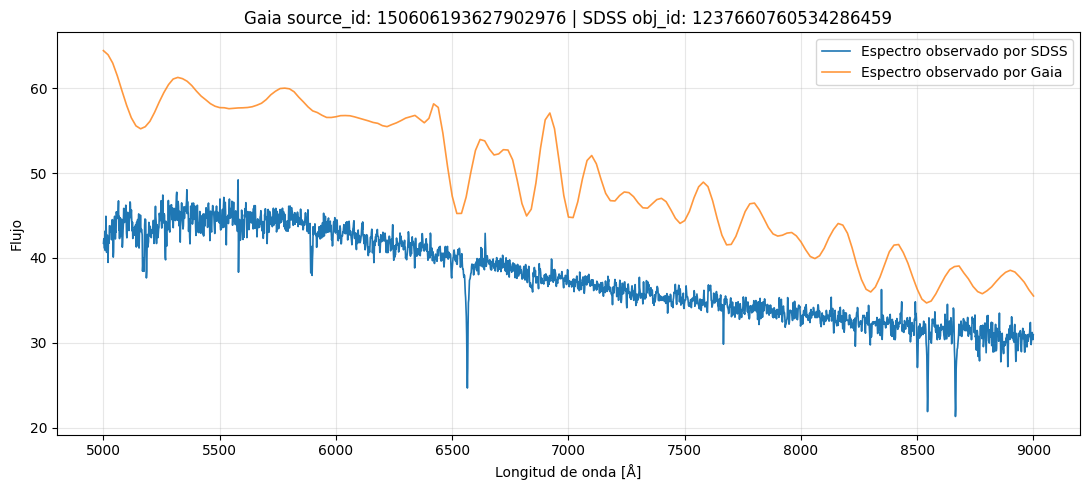

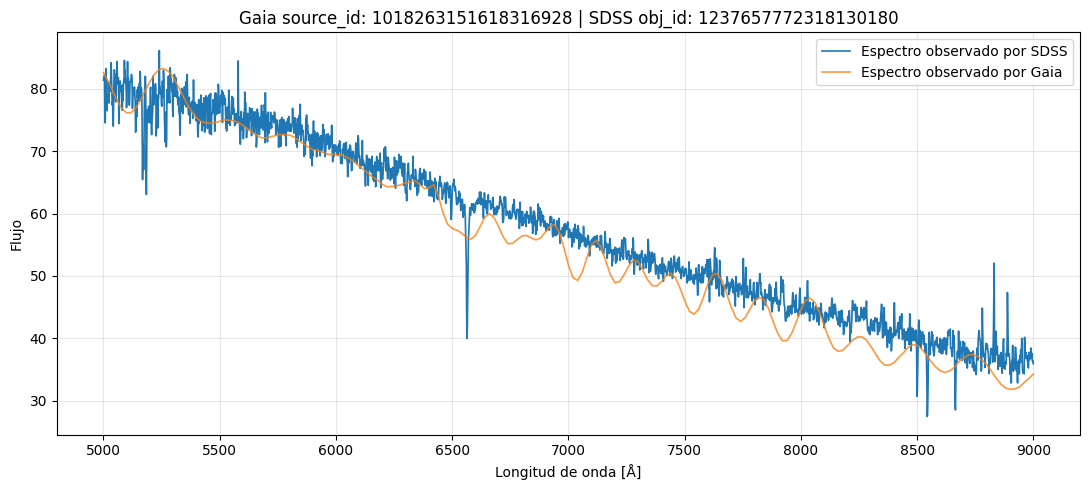

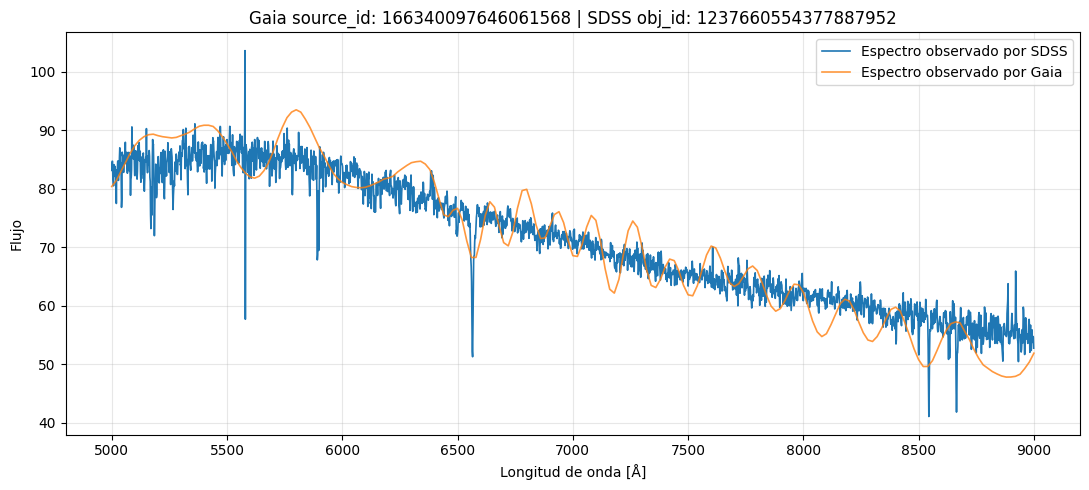

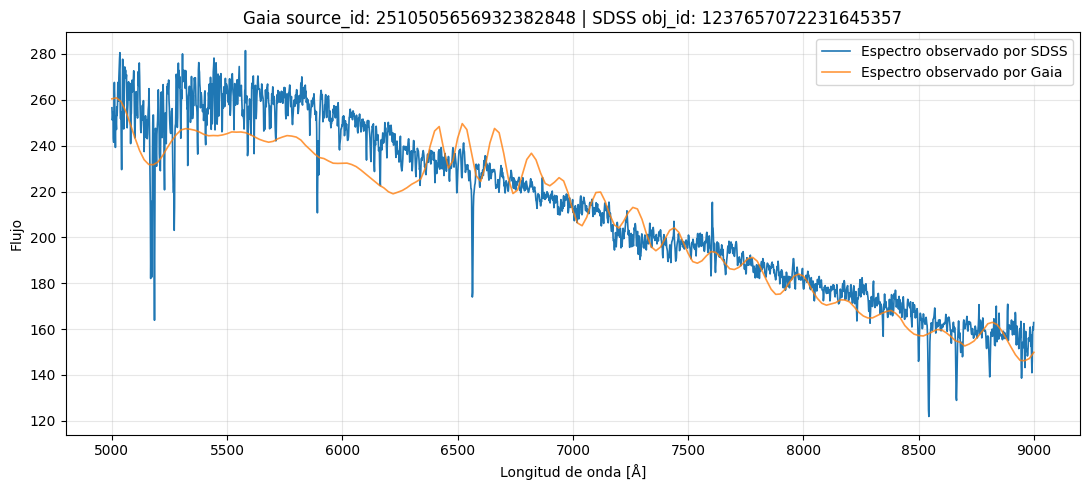

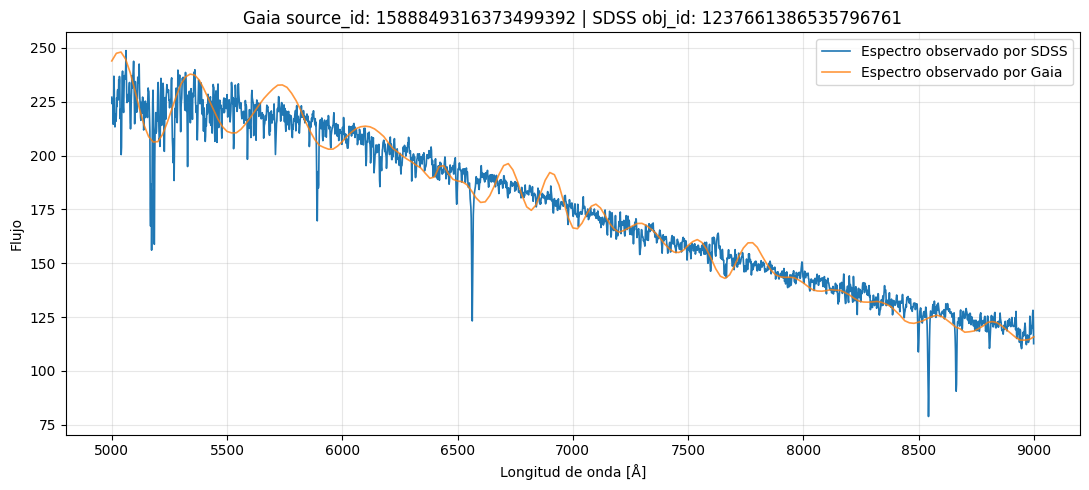

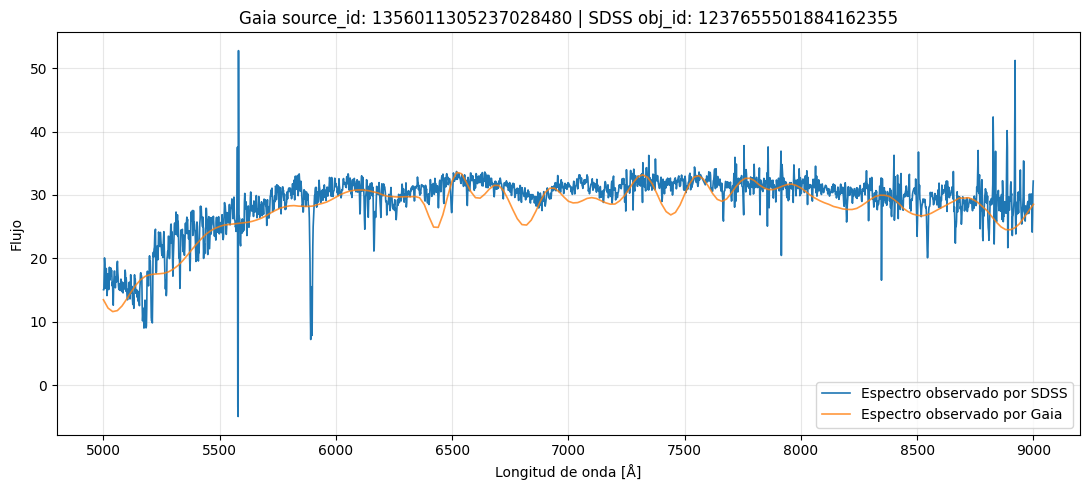

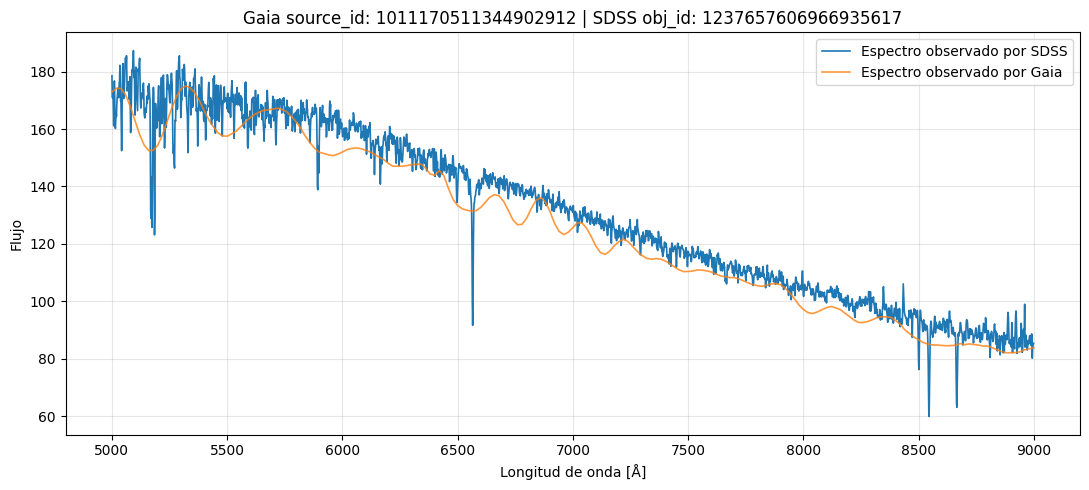

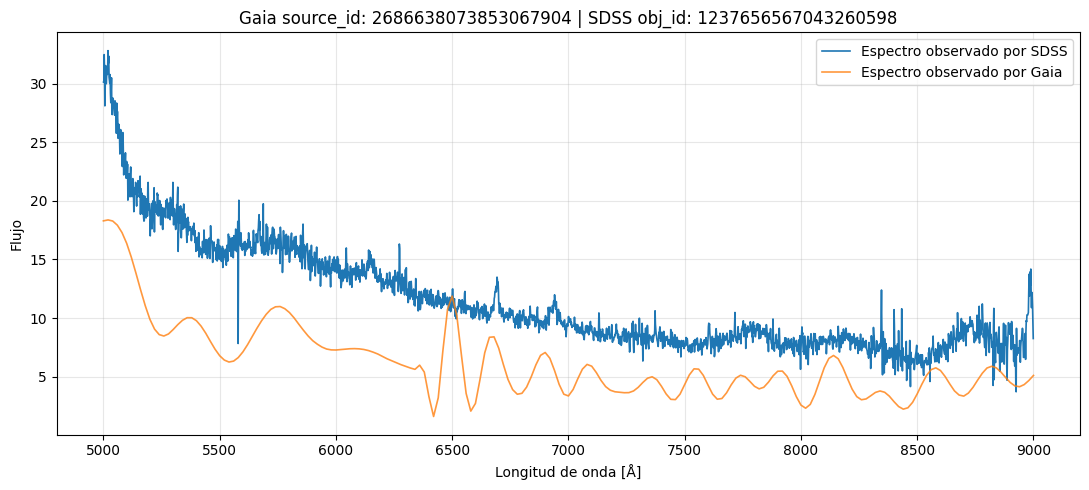

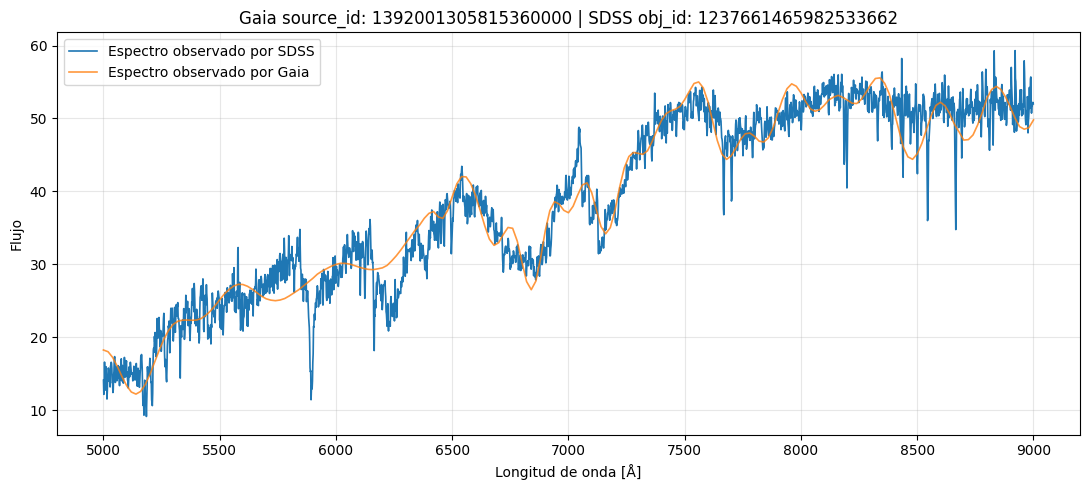

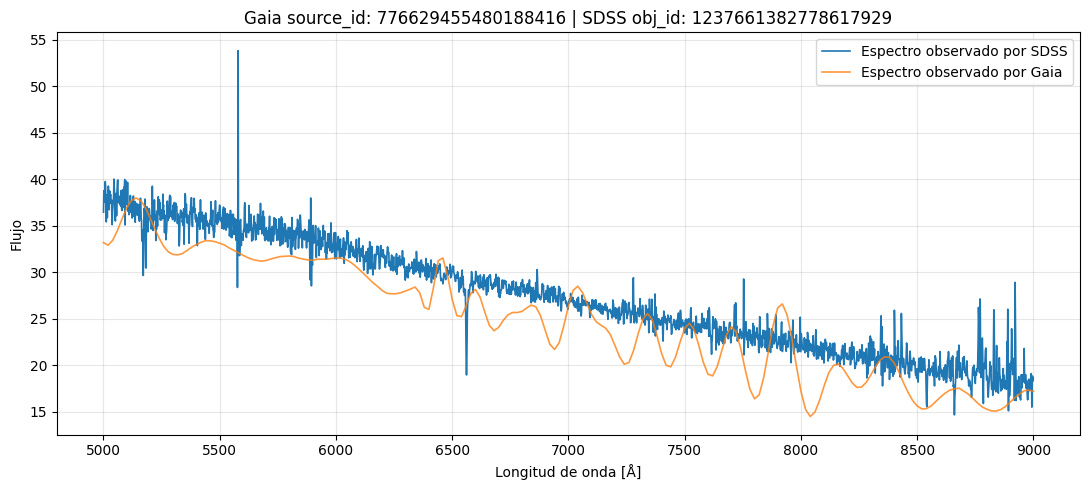

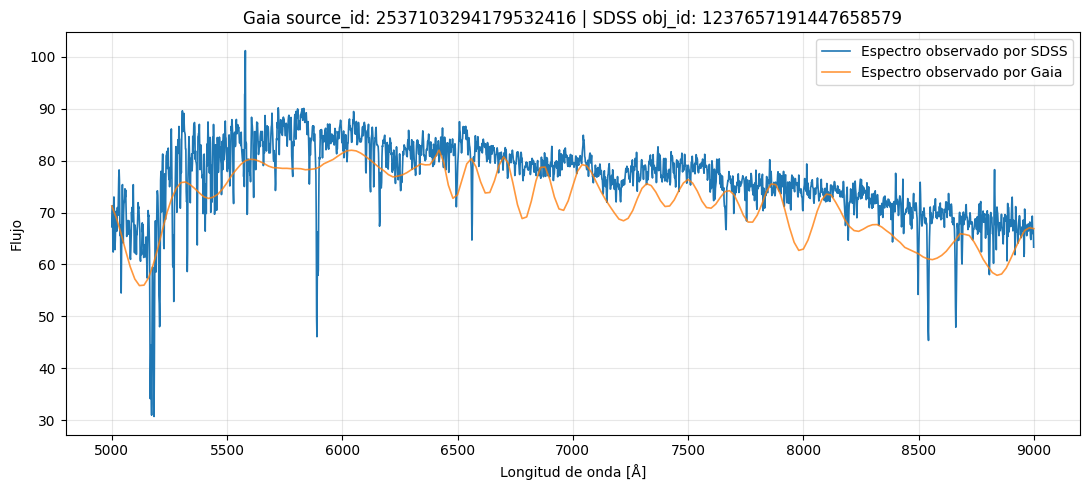

In [30]:
random_indices = plot_random_examples(
    X=X,
    y=y,
    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength,
    gaia_ID=X_id,
    sdss_ID=y_id,
    n_examples=15,
    seed=5 #2
)

In [31]:
# Calculamos el SNR de Gaia
gaia_snr_pixel = X / X_err

# Ajuste a la mediana 
gaia_snr = np.median(gaia_snr_pixel, axis=1)

# Para SDSS primero convertimos de ivar a SNR
# ivar = 1 / error²
# SNR = flujo / error = flujo * sqrt(ivar)

# Consideramos solo valores mayores que 0 , dado que los demás tendrían valor de error infinito
sdss_snr_pixel = np.full(y.shape, np.nan, dtype=float)
valid_sdss_pixel = y_ivar > 0

sdss_snr_pixel[valid_sdss_pixel] = (
    y[valid_sdss_pixel]
    * np.sqrt(y_ivar[valid_sdss_pixel])
)

sdss_snr = np.nanmedian(sdss_snr_pixel, axis=1)

c:\Users\javier\repos\master-ia\trabajo-fin-master\solution\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


In [32]:
# Definimos percentiles
gaia_snr_threshold = np.nanpercentile(gaia_snr, 5)
sdss_snr_threshold = np.nanpercentile(sdss_snr, 5)

# Rango válido tras descartes
valid_snr = (
    np.isfinite(gaia_snr)
    & np.isfinite(sdss_snr)
    & (gaia_snr > gaia_snr_threshold)
    & (sdss_snr > sdss_snr_threshold)
)

# Aplicamos máscara
X = X[valid_snr]
X_err = X_err[valid_snr]

y = y[valid_snr]
y_ivar = y_ivar[valid_snr]

X_id = X_id[valid_snr]
y_id = y_id[valid_snr]

gaia_snr = gaia_snr[valid_snr]
sdss_snr = sdss_snr[valid_snr]

In [33]:
# Calculamos la escala de los espectros
gaia_scale = np.nanmedian(np.abs(X), axis=1)
sdss_scale = np.nanmedian(np.abs(y), axis=1)

valid_scale = (
    np.isfinite(gaia_scale)
    & np.isfinite(sdss_scale)
    & (gaia_scale > 0)
    & (sdss_scale > 0)
)

# Ratio Gaia / SDSS
scale_ratio = np.full(
    gaia_scale.shape,
    np.nan,
    dtype=float
)

scale_ratio[valid_scale] = (
    gaia_scale[valid_scale]
    / sdss_scale[valid_scale]
)


print(np.nanpercentile(scale_ratio, [0, 1, 2, 5, 10, 50, 90, 95, 98, 99, 100]))

[2.56450996e-02 6.43708318e-01 6.72499812e-01 7.23773402e-01
 8.04351616e-01 9.71410394e-01 1.20154662e+00 1.38666637e+00
 1.47614874e+00 1.57501292e+00 3.19724350e+01]


In [34]:
import numpy as np

X_model = X
y_model = y

finite_mask = (
    np.isfinite(X_model).all(axis=1)
    & np.isfinite(y_model).all(axis=1)
)

y_p1 = np.nanpercentile(y_model, 1, axis=1)
y_p99 = np.nanpercentile(y_model, 99, axis=1)
y_p5 = np.nanpercentile(y_model, 5, axis=1)
y_p95 = np.nanpercentile(y_model, 95, axis=1)
y_median = np.nanmedian(np.abs(y_model), axis=1) + 1e-8
y_difference5 = y_p95 - y_p5

y_dynamic_range = y_p99 - y_p1
y_relative_range = y_dynamic_range / y_median


X_p1 = np.nanpercentile(X_model, 1, axis=1)
X_p99 = np.nanpercentile(X_model, 99, axis=1)
X_p5 = np.nanpercentile(X_model, 5, axis=1)
X_p95 = np.nanpercentile(X_model, 95, axis=1)
X_median = np.nanmedian(np.abs(X_model), axis=1) + 1e-8
X_difference5 = X_p95 - X_p5

X_dynamic_range = X_p99 - X_p1
X_relative_range = X_dynamic_range / X_median

In [35]:
print(np.nanpercentile(y_median, [0, 1, 2, 5, 10, 50, 90, 95, 98, 99, 100]))

print(np.nanpercentile(y_difference5, [0, 1, 2, 5, 10, 50, 90, 95, 98, 99, 100]))

[3.65752554e+00 6.16463276e+00 6.67353386e+00 7.84984922e+00
 1.01318031e+01 4.61649132e+01 1.35363831e+02 1.69019342e+02
 2.05275688e+02 2.39683719e+02 5.67021191e+03]
[1.99524641e+00 5.31462023e+00 6.03068228e+00 7.44582644e+00
 9.52820282e+00 3.14960518e+01 9.60087784e+01 1.30851120e+02
 1.88382499e+02 2.32807702e+02 2.24987671e+03]


In [36]:
valid = (
    finite_mask
    # Calidad del espectro SDSS objetivo
    & (y_dynamic_range < np.nanpercentile(y_dynamic_range, 99))
    & (y_median > np.nanpercentile(y_median, 1))
    & (y_median < np.nanpercentile(y_median, 99))
    & (y_difference5 > np.nanpercentile(y_difference5, 1))
    # Coherencia Gaia-SDSS
    & (scale_ratio > np.nanpercentile(scale_ratio[np.isfinite(scale_ratio)], 5))
    & (scale_ratio < np.nanpercentile(scale_ratio[np.isfinite(scale_ratio)], 95))
)

print("Antes:", X_model.shape[0])
print("Después:", valid.sum())

X_model = X_model[valid]
y_model = y_model[valid]

Antes: 46743
Después: 40834


In [37]:
X_id = X_id[valid]
X_err = X_err[valid]

y_id = y_id[valid]
y_ivar = y_ivar[valid]

In [38]:
from sklearn.model_selection import train_test_split

# Separamos en train y temp, luego el temp lo usaremos para separar en test y validation para que los espectros queden mezclados

X_temp, X_test, X_id_temp, X_id_test, X_err_temp, X_err_test, y_temp, y_test, y_id_temp, y_id_test, y_ivar_temp, y_ivar_test = train_test_split(
    X_model,
    X_id,
    X_err,
    y_model,
    y_id,
    y_ivar,
    test_size=0.2,
    random_state=23,
    shuffle=True
)

X_train, X_val, X_id_train, X_id_val, X_err_train, X_err_val, y_train, y_val , y_id_train, y_id_val, y_ivar_train, y_ivar_val= train_test_split(
    X_temp,
    X_id_temp,
    X_err_temp,
    y_temp,
    y_id_temp,
    y_ivar_temp,
    test_size=0.2,
    random_state=23,
    shuffle=True
)

In [39]:
# Guardamos los datos de entrenamiento para usarlos en otros archivos
split_dir = Path("../data/splits")
split_dir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    split_dir / "processed_data_no_duplicates.npz",

    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    X_id_train = X_id_train,
    X_id_val = X_id_val,
    X_id_test = X_id_test,
    X_err_train = X_err_train,
    X_err_val = X_err_val,
    X_err_test = X_err_test,

    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    y_id_train = y_id_train,
    y_id_val = y_id_val,
    y_id_test = y_id_test,
    y_ivar_train = y_ivar_train,
    y_ivar_val = y_ivar_val,
    y_ivar_test = y_ivar_test,

    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength
)
